In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install opendatasets

In [3]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/soham0666/fingerprint-to-blood-group-prediction')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

  soham0666


Your Kaggle Key:

  ········


Dataset URL: https://www.kaggle.com/datasets/soham0666/fingerprint-to-blood-group-prediction


100%|██████████| 56.3M/56.3M [00:00<00:00, 140MB/s]


In [4]:
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.20,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.05
)

train_generator = datagen.flow_from_directory(
    r'/kaggle/working/fingerprint-to-blood-group-prediction/main_dataset_after_split/Fingerprint Dataset for Blood Group Classification',
    target_size = (256,256),
    batch_size = 32,
    class_mode = 'categorical',
    subset = 'training',
    shuffle=True
)

test_generator = datagen.flow_from_directory(
    r'/kaggle/working/fingerprint-to-blood-group-prediction/main_dataset_after_split/Fingerprint Dataset for Blood Group Classification',
    target_size = (256,256),
    batch_size = 32,
    class_mode = 'categorical',
    subset = 'validation',
    shuffle = False
)

2026-04-08 13:41:11.590491: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775655671.783860      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775655671.845234      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775655672.344255      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775655672.344286      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775655672.344288      55 computation_placer.cc:177] computation placer alr

Found 4269 images belonging to 8 classes.
Found 1064 images belonging to 8 classes.


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, MaxPooling2D, Dropout, Conv2D, Flatten

model = Sequential([
    Conv2D(32, kernel_size = (3,3), activation = 'relu', padding = 'same', input_shape = (256,256,3)),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Conv2D(64, kernel_size = (3,3), activation = 'relu', padding = 'same'),
    MaxPooling2D(2,2),
    Dropout(0.4),
    
    Conv2D(128, kernel_size = (3,3), activation = 'relu', padding = 'same'),
    MaxPooling2D(2,2),
    Dropout(0.4),

    Conv2D(256, kernel_size = (3,3), activation = 'relu', padding = 'same'),
    MaxPooling2D(2,2),
    Dropout(0.4),

    Conv2D(512, kernel_size = (3,3), activation = 'relu', padding = 'same'),
    MaxPooling2D(2,2),
    Dropout(0.4),

    Flatten(),
    Dense(1024, activation = 'relu'),
    Dropout(0.5),

    Dense(8, activation = 'softmax')
    
])

In [9]:
from tensorflow.keras.optimizers import SGD

optimizer = SGD(learning_rate=0.001, momentum=0.9)
model.compile(loss = 'categorical_crossentropy', optimizer = optimizer, metrics = ['accuracy'])

In [10]:
model.summary()
history = model.fit(train_generator, epochs = 50, validation_data = test_generator)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │    33,555,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         8,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,132,232 (134.02 MB)

 Trainable params: 35,132,232 (134.02 MB)

 Non-trainable params: 0 (0.00 B)

...

  1/134 ━━━━━━━━━━━━━━━━━━━━ 32:51 15s/step - accuracy: 0.0625 - loss: 2.5181

I0000 00:00:1775655780.832713     215 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


104/134 ━━━━━━━━━━━━━━━━━━━━ 11s 386ms/step - accuracy: 0.1386 - loss: 2.1729

2026-04-08 13:43:43.318010: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 13:43:43.482078: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


134/134 ━━━━━━━━━━━━━━━━━━━━ 90s 568ms/step - accuracy: 0.1417 - loss: 2.1547 - val_accuracy: 0.1701 - val_loss: 2.0651
Epoch 2/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 64s 478ms/step - accuracy: 0.1991 - loss: 1.9700 - val_accuracy: 0.3017 - val_loss: 1.9485
Epoch 3/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 63s 469ms/step - accuracy: 0.2917 - loss: 1.7571 - val_accuracy: 0.3750 - val_loss: 1.8465
Epoch 4/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 64s 477ms/step - accuracy: 0.3541 - loss: 1.6034 - val_accuracy: 0.4060 - val_loss: 1.7566
Epoch 5/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 65s 481ms/step - accuracy: 0.3840 - loss: 1.5340 - val_accuracy: 0.4041 - val_loss: 1.6583
Epoch 6/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 65s 481ms/step - accuracy: 0.4004 - loss: 1.4212 - val_accuracy: 0.4239 - val_loss: 1.6142
Epoch 7/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 65s 482ms/step - accuracy: 0.4428 - loss: 1.3347 - val_accuracy: 0.4568 - val_loss: 1.5483
Epoch 8/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 64s 477ms/step - accuracy: 0.4436 - loss: 1.3312 - val

In [11]:
# OR (recommended modern format)
model.save("fingerprint_model.keras")

In [12]:
import numpy as np
from sklearn.metrics import classification_report

# Get predictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_generator.classes

# Class labels
class_labels = list(test_generator.class_indices.keys())

# Print report
print(classification_report(y_true, y_pred, target_names=class_labels))

34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 371ms/step
              precision    recall  f1-score   support

          A+       0.81      0.85      0.83       102
          A-       0.70      0.76      0.73       143
         AB+       0.88      0.79      0.83       130
         AB-       0.89      0.72      0.80       141
          B+       0.82      0.86      0.84       119
          B-       0.88      0.90      0.89       138
          O+       0.73      0.92      0.82       159
          O-       0.86      0.69      0.76       132

    accuracy                           0.81      1064
   macro avg       0.82      0.81      0.81      1064
weighted avg       0.82      0.81      0.81      1064



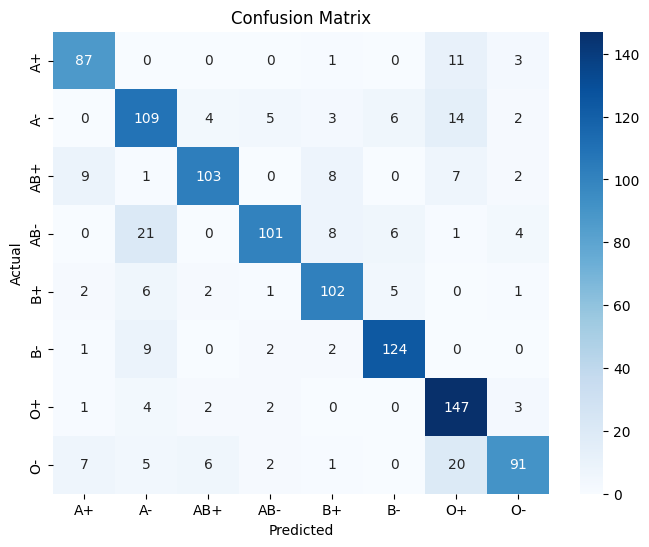

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
from tensorflow.keras.models import load_model

model = load_model("fingerprint_model.keras")

Found 440 images belonging to 8 classes.
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step

===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

          A+       0.85      0.84      0.84        55
          A-       0.80      0.85      0.82        55
         AB+       0.87      0.87      0.87        55
         AB-       1.00      0.67      0.80        55
          B+       0.92      0.98      0.95        55
          B-       0.83      0.89      0.86        55
          O+       0.55      0.95      0.70        55
          O-       0.96      0.40      0.56        55

    accuracy                           0.81       440
   macro avg       0.85      0.81      0.80       440
weighted avg       0.85      0.81      0.80       440



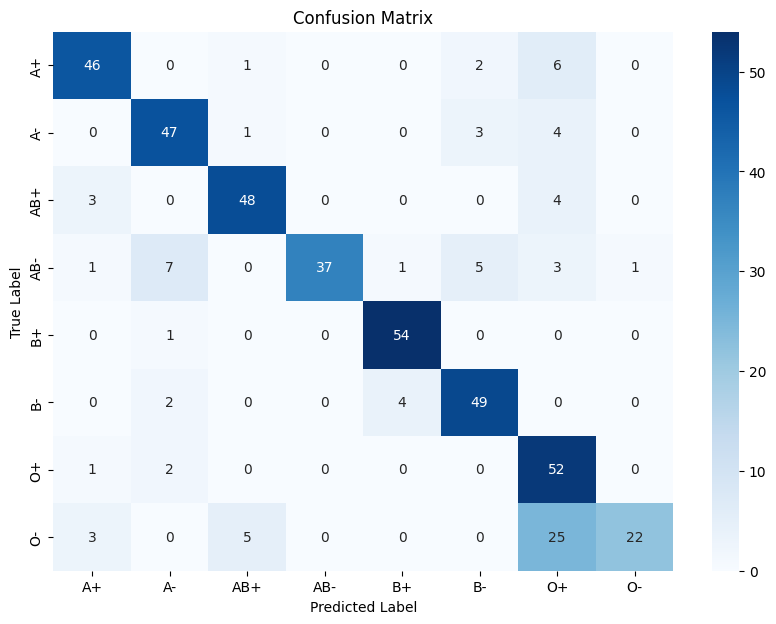

In [18]:
# ================================
# 1. IMPORTS
# ================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix


# ================================
# 2. LOAD MODEL
# ================================
model_path = "/kaggle/working/fingerprint_model.keras"  # change if needed
model = load_model(model_path)


# ================================
# 3. LOAD PREDICTION DATASET
# ================================
prediction_dir = "/kaggle/working/fingerprint-to-blood-group-prediction/prediction_dataset"

datagen = ImageDataGenerator(rescale=1./255)

prediction_generator = datagen.flow_from_directory(
    prediction_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # 🚨 VERY IMPORTANT
)


# ================================
# 4. PREDICTIONS
# ================================
prediction_generator.reset()

y_pred_probs = model.predict(prediction_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = prediction_generator.classes
class_labels = list(prediction_generator.class_indices.keys())


# ================================
# 5. CLASSIFICATION REPORT
# ================================
print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


# ================================
# 6. CONFUSION MATRIX (RAW)
# ================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()